# Exploratory Data Analysis — BAM Risk Assessment

Loads all data sources, profiles their structure and quality, and produces
visualisations to build intuition before modelling.

**Sections**
1. Setup
2. Instruments
3. Portfolio Positions
4. Prices — Raw Quality Audit
5. Prices — Cleaning
6. Returns
7. Stress Scenarios

## 1. Setup

In [ ]:
from utils import setup_repo_root

repo_root = setup_repo_root()
print("Working directory:", repo_root)

Working directory: /home/martin/python/risk-assessment


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from data_loader import (
    clean_prices,
    load_instruments,
    load_positions,
    load_prices,
    load_scenarios,
)

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 4)})
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

## 2. Instruments

In [22]:
instruments = load_instruments()
print(f"Shape: {instruments.shape}")
instruments.dtypes

Shape: (18, 11)


instrument_id                   str
instrument_name                 str
asset_class                     str
sub_class                       str
sector                          str
currency                        str
country                         str
credit_rating                   str
maturity_date        datetime64[us]
coupon_rate                 float64
modified_duration           float64
dtype: object

In [23]:
instruments.head(10)

,instrument_id,instrument_name,asset_class,sub_class,sector,currency,country,credit_rating,maturity_date,coupon_rate,modified_duration
0,NESN,Nestle SA,EQUITY,SWISS_EQUITY,Consumer Staples,CHF,CH,NaN,NaT,NaN,NaN
1,NOVN,Novartis AG,EQUITY,SWISS_EQUITY,Healthcare,CHF,CH,NaN,NaT,NaN,NaN
2,ROG,Roche Holding AG,EQUITY,SWISS_EQUITY,Healthcare,CHF,CH,NaN,NaT,NaN,NaN
3,UBSG,UBS Group AG,EQUITY,SWISS_EQUITY,Financials,CHF,CH,NaN,NaT,NaN,NaN
4,ABBN,ABB Ltd,EQUITY,SWISS_EQUITY,Industrials,CHF,CH,NaN,NaT,NaN,NaN
5,SREN,Swiss Re AG,EQUITY,SWISS_EQUITY,Insurance,CHF,CH,NaN,NaT,NaN,NaN
6,SAN_FP,Sanofi SA,EQUITY,EUR_EQUITY,Healthcare,CHF,FR,NaN,NaT,NaN,NaN
7,SIE_GR,Siemens AG,EQUITY,EUR_EQUITY,Industrials,CHF,DE,NaN,NaT,NaN,NaN
8,ASML_NA,ASML Holding NV,EQUITY,EUR_EQUITY,Technology,CHF,NL,NaN,NaT,NaN,NaN
9,ALV_GR,Allianz SE,EQUITY,EUR_EQUITY,Insurance,CHF,DE,NaN,NaT,NaN,NaN


In [24]:
print("Null counts per column:")
display(instruments.isna().sum().rename("null_count").to_frame())

print("\nBreakdown by asset_class / sub_class:")
display(
    instruments.groupby(["asset_class", "sub_class"])
    .size()
    .rename("count")
    .reset_index()
)

Null counts per column:


,null_count
instrument_id,0
instrument_name,0
asset_class,0
sub_class,0
sector,5
currency,0
country,0
credit_rating,10
maturity_date,10
coupon_rate,10



Breakdown by asset_class / sub_class:


,asset_class,sub_class,count
0,CORP_BOND,CHF_CORP,3
1,EQUITY,EUR_EQUITY,4
2,EQUITY,SWISS_EQUITY,6
3,GOVT_BOND,CHF_GOVT,3
4,GOVT_BOND,EUR_GOVT,2


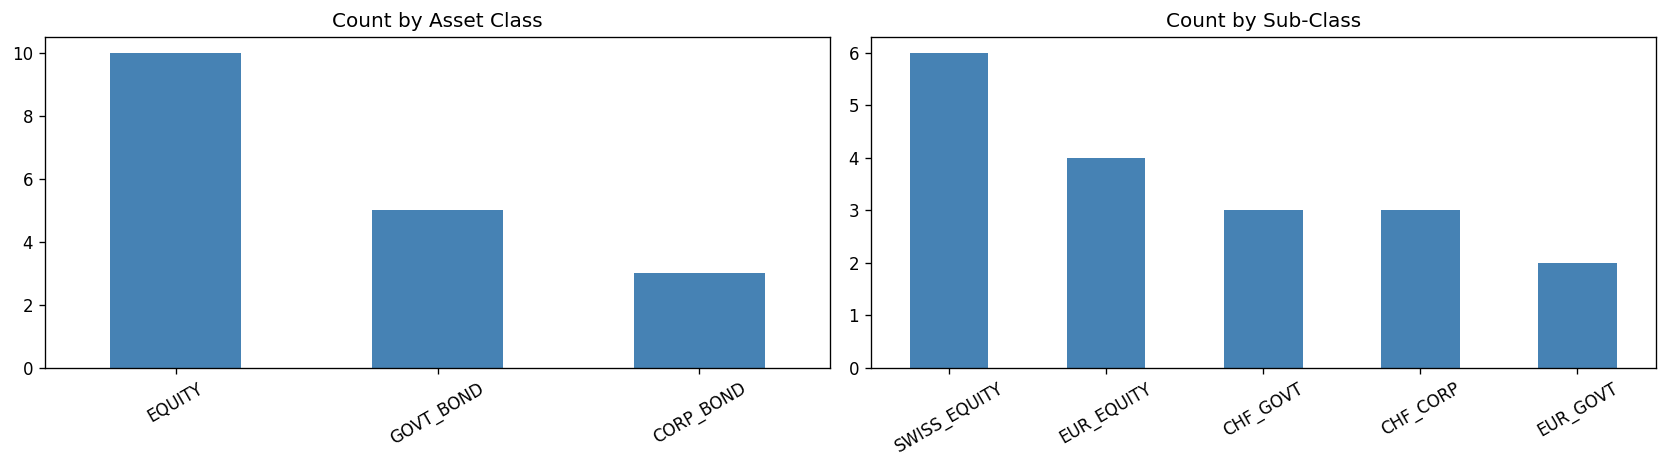

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

instruments["asset_class"].value_counts().plot.bar(
    ax=axes[0], title="Count by Asset Class", color="steelblue"
)
instruments["sub_class"].value_counts().plot.bar(
    ax=axes[1], title="Count by Sub-Class", color="steelblue"
)
for ax in axes:
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [25]:
# Fixed-income instruments: ratings, coupons, and duration profile
fi = instruments[instruments["modified_duration"].notna()].copy()
print(f"Fixed-income instruments: {len(fi)}")
fi[["instrument_name", "sub_class", "credit_rating", "coupon_rate", "modified_duration"]].sort_values(
    "modified_duration", ascending=False
)

Fixed-income instruments: 8


,instrument_name,sub_class,credit_rating,coupon_rate,modified_duration
12,Swiss Confederation 10Y,CHF_GOVT,AAA,0.01,8.70
14,French OAT 7Y,EUR_GOVT,AA,0.02,6.20
16,Novartis Corp Bond 5.1Y,CHF_CORP,AA-,0.01,5.10
11,Swiss Confederation 5Y,CHF_GOVT,AAA,0.01,4.60
13,German Bund 5Y,EUR_GOVT,AAA,0.01,4.50
17,UBS Corp Bond 4.2Y,CHF_CORP,A+,0.02,4.20
15,Nestle Corp Bond 3.8Y,CHF_CORP,AA,0.01,3.80
10,Swiss Confederation 2Y,CHF_GOVT,AAA,0.01,1.90


## 3. Portfolio Positions

In [26]:
positions = load_positions()
print(f"Shape:         {positions.shape}")
print(f"Snapshot date: {positions['snapshot_date'].unique()}")
print(f"Total weight:  {positions['weight'].sum():.6f}")
print(f"Total NAV:     CHF {positions['market_value_chf'].sum():,.0f}")

Shape:         (18, 16)
Snapshot date: <DatetimeArray>
['2026-03-18 00:00:00']
Length: 1, dtype: datetime64[us]
Total weight:  1.000000
Total NAV:     CHF 500,000,000


### 3.1 Exploring Positions History Table

`load_positions` returns one row per instrument — the most recent snapshot. The cells below show the raw position history table and explain why `QUALIFY ROW_NUMBER()` is a good choice for "latest record per group" compared with the two obvious alternatives.

In [41]:
import duckdb

# Inspect the raw positions_history table — multiple snapshots per instrument.
with duckdb.connect("data/reference.duckdb", read_only=True) as con:
    history = con.execute(
        "SELECT instrument_id, snapshot_date, market_value_chf, weight "
        "FROM positions_history "
        "ORDER BY instrument_id, snapshot_date"
    ).fetchdf()

print(f"Total rows in positions_history: {len(history)}")
print(f"Distinct instruments:            {history['instrument_id'].nunique()}")
print(f"Distinct snapshot dates:         {sorted(history['snapshot_date'].unique())}")
history.head(12)

Total rows in positions_history: 90
Distinct instruments:            18
Distinct snapshot dates:         [Timestamp('2025-04-01 00:00:00'), Timestamp('2025-06-27 00:00:00'), Timestamp('2025-09-24 00:00:00'), Timestamp('2025-12-22 00:00:00'), Timestamp('2026-03-18 00:00:00')]


,instrument_id,snapshot_date,market_value_chf,weight
0,ABBN,2025-04-01,"15,689,558.44",0.03
1,ABBN,2025-06-27,"13,365,383.64",0.03
2,ABBN,2025-09-24,"13,734,477.35",0.03
3,ABBN,2025-12-22,"13,823,265.69",0.03
4,ABBN,2026-03-18,"15,000,000.00",0.03
5,ALV_GR,2025-04-01,"9,460,513.11",0.02
6,ALV_GR,2025-06-27,"9,949,096.97",0.02
7,ALV_GR,2025-09-24,"9,511,696.48",0.02
8,ALV_GR,2025-12-22,"10,076,495.62",0.02
9,ALV_GR,2026-03-18,"10,000,000.00",0.02


### 3.2 Alternative A — `ROW_NUMBER() OVER (PARTITION BY ...)` as a subquery

This is the standard SQL-compatible form that works on any database engine. It assigns a rank within each instrument group in an inner query, then filters to rank 1 in the outer `WHERE` clause. `QUALIFY` is syntactic sugar that collapses this two-level structure into one.

In [45]:
with duckdb.connect("data/reference.duckdb", read_only=True) as con:
    rn_subquery_result = con.execute("""
        SELECT instrument_id, snapshot_date
        FROM (
            SELECT
                instrument_id,
                snapshot_date,
                ROW_NUMBER() OVER (
                    PARTITION BY instrument_id
                    ORDER BY snapshot_date DESC
                ) AS rn
            FROM positions_history
        ) ranked
        WHERE rn = 1
        ORDER BY instrument_id
    """).fetchdf()

print(f"Rows returned: {len(rn_subquery_result)}  ✓ (correct)")
print()
print("The two queries below are exactly equivalent — QUALIFY is just shorter:")
print()
print("  -- Standard SQL (subquery required)")
print("  SELECT * FROM (")
print("      SELECT *, ROW_NUMBER() OVER (PARTITION BY instrument_id ORDER BY snapshot_date DESC) AS rn")
print("      FROM positions_history")
print("  ) ranked WHERE rn = 1")
print()
print("  -- DuckDB QUALIFY (no subquery needed)")
print("  SELECT * FROM positions_history")
print("  QUALIFY ROW_NUMBER() OVER (PARTITION BY instrument_id ORDER BY snapshot_date DESC) = 1")
rn_subquery_result

Rows returned: 18  ✓ (correct)

The two queries below are exactly equivalent — QUALIFY is just shorter:

  -- Standard SQL (subquery required)
  SELECT * FROM (
      SELECT *, ROW_NUMBER() OVER (PARTITION BY instrument_id ORDER BY snapshot_date DESC) AS rn
      FROM positions_history
  ) ranked WHERE rn = 1

  -- DuckDB QUALIFY (no subquery needed)
  SELECT * FROM positions_history
  QUALIFY ROW_NUMBER() OVER (PARTITION BY instrument_id ORDER BY snapshot_date DESC) = 1


,instrument_id,snapshot_date
0,ABBN,2026-03-18
1,ALV_GR,2026-03-18
2,ASML_NA,2026-03-18
3,CHGOV_10Y,2026-03-18
4,CHGOV_2Y,2026-03-18
5,CHGOV_5Y,2026-03-18
6,DBRGOV_5Y,2026-03-18
7,FRGOV_7Y,2026-03-18
8,NESN,2026-03-18
9,NESN_CORP,2026-03-18


### 3.3 Alternative B — scalar subquery
This approach assumes every instrument was last updated on the *global* maximum date.  If any instrument has a stale or missing snapshot it would be silently dropped, producing a positions table with fewer than 18 rows.

We simulate the failure by temporarily treating one instrument as stale.

In [43]:
global_max = history["snapshot_date"].max()
stale_mask = history["instrument_id"] == history["instrument_id"].iloc[0]
removed_instrument_id = history.loc[stale_mask, "instrument_id"].iloc[0]
simulated = history.copy()
simulated.loc[stale_mask, "snapshot_date"] = global_max - pd.Timedelta(days=7)

scalar_subquery_result = simulated[simulated["snapshot_date"] == global_max]
print(f"Rows returned by scalar-subquery approach: {len(scalar_subquery_result)}")
print(
    f"{removed_instrument_id} (deliberately staled) is missing: "
    f"{removed_instrument_id not in scalar_subquery_result['instrument_id'].values}"
)

Rows returned by scalar-subquery approach: 17
ABBN (deliberately staled) is missing: True


### 3.4 Alternative C — correlated subquery

A correlated subquery scopes the inner `MAX()` to the current instrument, so it handles stale instruments correctly — unlike the scalar subquery in Alternative A.

The cost is performance: the inner `SELECT MAX(...)` re-executes once per row in the outer table, making this **O(N²)** in the number of history rows. The window-function approach is **O(N log N)** because it sorts once and scans once. The difference is negligible for 90 rows but matters at scale.

In [44]:
with duckdb.connect("data/reference.duckdb", read_only=True) as con:
    correlated_result = con.execute("""
        SELECT instrument_id, snapshot_date
        FROM positions_history p
        WHERE snapshot_date = (
            SELECT MAX(p2.snapshot_date)
            FROM positions_history p2
            WHERE p2.instrument_id = p.instrument_id  -- ← correlated: references outer row
        )
        ORDER BY instrument_id
    """).fetchdf()

print(f"Rows returned: {len(correlated_result)}  ✓ (correct — stale instruments included)")
print()

# Confirm all three correct approaches return identical results
assert rn_subquery_result.equals(correlated_result), "Results differ!"
print("ROW_NUMBER subquery and correlated subquery return identical results.")
correlated_result

Rows returned: 18  ✓ (correct — stale instruments included)

ROW_NUMBER subquery and correlated subquery return identical results.


,instrument_id,snapshot_date
0,ABBN,2026-03-18
1,ALV_GR,2026-03-18
2,ASML_NA,2026-03-18
3,CHGOV_10Y,2026-03-18
4,CHGOV_2Y,2026-03-18
5,CHGOV_5Y,2026-03-18
6,DBRGOV_5Y,2026-03-18
7,FRGOV_7Y,2026-03-18
8,NESN,2026-03-18
9,NESN_CORP,2026-03-18


### 3.5 Position Overview

,instrument_id,instrument_name,sub_class,market_value_chf,weight
0,CHGOV_2Y,Swiss Confederation 2Y,CHF_GOVT,"75,000,000.00",15.00%
1,CHGOV_5Y,Swiss Confederation 5Y,CHF_GOVT,"60,000,000.00",12.00%
2,CHGOV_10Y,Swiss Confederation 10Y,CHF_GOVT,"50,000,000.00",10.00%
3,DBRGOV_5Y,German Bund 5Y,EUR_GOVT,"40,000,000.00",8.00%
4,NESN,Nestle SA,SWISS_EQUITY,"30,000,000.00",6.00%
5,NESN_CORP,Nestle Corp Bond 3.8Y,CHF_CORP,"30,000,000.00",6.00%
6,NOVN,Novartis AG,SWISS_EQUITY,"27,500,000.00",5.50%
7,ROG,Roche Holding AG,SWISS_EQUITY,"25,000,000.00",5.00%
8,FRGOV_7Y,French OAT 7Y,EUR_GOVT,"25,000,000.00",5.00%
9,NOVN_CORP,Novartis Corp Bond 5.1Y,CHF_CORP,"25,000,000.00",5.00%


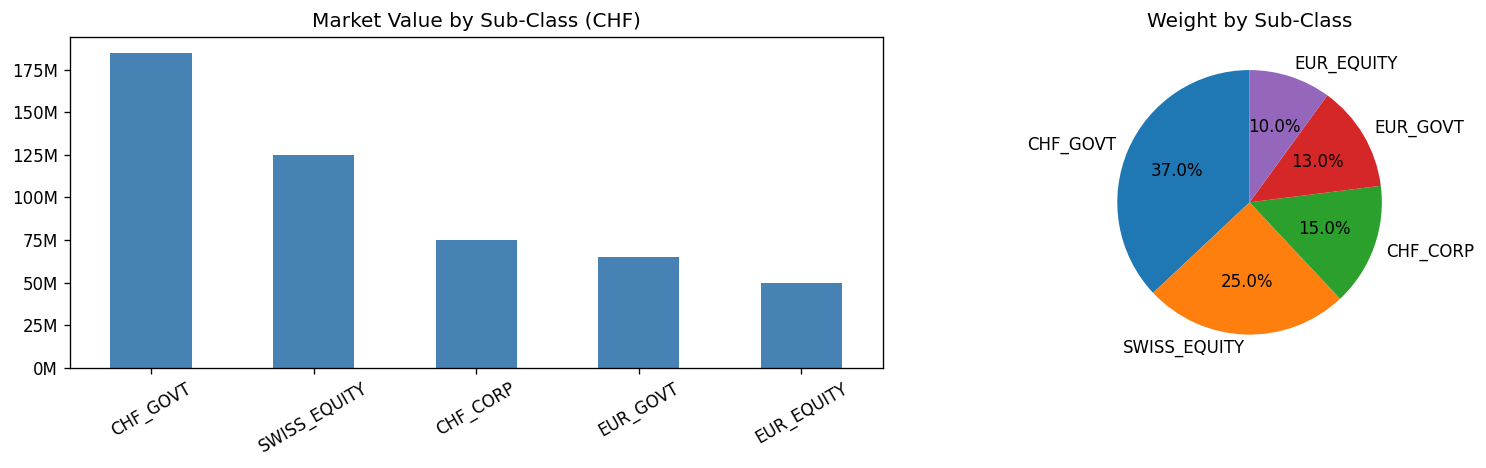

In [9]:
top10 = (
    positions.sort_values("market_value_chf", ascending=False)
    .head(10)[["instrument_id", "instrument_name", "sub_class", "market_value_chf", "weight"]]
    .assign(weight=lambda df: df["weight"].map("{:.2%}".format))
    .reset_index(drop=True)
)
display(top10)

alloc = positions.groupby("sub_class")["market_value_chf"].sum().sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

alloc.plot.bar(ax=axes[0], title="Market Value by Sub-Class (CHF)", color="steelblue")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))

alloc.plot.pie(ax=axes[1], title="Weight by Sub-Class", autopct="%1.1f%%", startangle=90, ylabel="")

plt.tight_layout()
plt.show()

In [10]:
print("Currency exposure (CHF market value):")
display(
    positions.groupby("currency")["market_value_chf"]
    .sum()
    .sort_values(ascending=False)
    .to_frame()
)

print("\nSector exposure (equities only):")
display(
    positions[positions["sector"].notna()]
    .groupby("sector")["market_value_chf"]
    .sum()
    .sort_values(ascending=False)
    .to_frame()
)

Currency exposure (CHF market value):


,market_value_chf
currency,
CHF,"500,000,000.00"



Sector exposure (equities only):


,market_value_chf
sector,
Healthcare,"92,500,000.00"
Consumer Staples,"60,000,000.00"
Financials,"37,500,000.00"
Industrials,"27,500,000.00"
Insurance,"20,000,000.00"
Technology,"12,500,000.00"


## 4. Prices — Raw Quality Audit

In [11]:
raw = load_prices()
print(f"Shape:       {raw.shape}")
print(f"Date range:  {raw['date'].min()} → {raw['date'].max()}")
print(f"Instruments: {raw['instrument_id'].nunique()}")
raw.head()

Shape:       (4555, 3)
Date range:  2025-03-31 00:00:00 → 2026-03-18 00:00:00
Instruments: 18


,date,instrument_id,price
0,2025-03-31,ABBN,44.80
1,2025-03-31,ALV_GR,258.90
2,2025-03-31,ASML_NA,685.00
3,2025-03-31,CHGOV_10Y,98.50
4,2025-03-31,CHGOV_2Y,100.20


In [12]:
# Missing values per instrument
nan_by_instrument = (
    raw[raw["price"].isna()]
    .groupby("instrument_id")
    .size()
    .rename("nan_count")
    .sort_values(ascending=False)
)
print(f"Total NaN prices: {nan_by_instrument.sum()}")
display(nan_by_instrument.to_frame())

# Duplicate rows
dups = raw[raw.duplicated(subset=["date", "instrument_id"], keep=False)]
print(f"\nDuplicate rows: {len(dups)}")
display(dups.sort_values(["instrument_id", "date"]).head(8))

# Outlier scan: flag prices > 4x or < 0.25x the local rolling median
raw_sorted = raw.dropna().sort_values(["instrument_id", "date"])
rolling_med = raw_sorted.groupby("instrument_id")["price"].transform(
    lambda s: s.rolling(5, center=True, min_periods=1).median()
)
ratio = raw_sorted["price"] / rolling_med
outliers = raw_sorted[(ratio > 4) | (ratio < 0.25)].copy()
outliers["ratio_to_median"] = ratio[outliers.index].round(2)
print(f"\nSuspected outliers: {len(outliers)}")
display(outliers)

Total NaN prices: 2


,nan_count
instrument_id,
NESN,2



Duplicate rows: 2


,date,instrument_id,price
586,2025-05-14,NOVN,83.12
587,2025-05-14,NOVN,83.28



Suspected outliers: 1


,date,instrument_id,price,ratio_to_median
935,2025-06-10,UBSG,142.45,5.09


## 5. Prices — Cleaning

In [13]:
clean = clean_prices(raw)
print(f"Raw shape:            {raw.shape}")
print(f"Clean shape:          {clean.shape}")
print(f"NaNs remaining:       {clean['price'].isna().sum()}")
print(f"Duplicates remaining: {clean.duplicated(subset=['date', 'instrument_id']).sum()}")

# Latest clean price per instrument
latest = (
    clean.sort_values("date")
    .groupby("instrument_id", as_index=False)
    .last()
    .rename(columns={"price": "latest_price", "date": "latest_date"})
    .merge(instruments[["instrument_id", "sub_class"]], on="instrument_id")
    .sort_values(["sub_class", "instrument_id"])
    .reset_index(drop=True)
)
latest

Raw shape:            (4555, 3)
Clean shape:          (4554, 3)
NaNs remaining:       0
Duplicates remaining: 0


,instrument_id,latest_date,latest_price,sub_class
0,NESN_CORP,2026-03-18,94.79,CHF_CORP
1,NOVN_CORP,2026-03-18,95.39,CHF_CORP
2,UBSG_CORP,2026-03-18,103.17,CHF_CORP
3,CHGOV_10Y,2026-03-18,105.23,CHF_GOVT
4,CHGOV_2Y,2026-03-18,101.44,CHF_GOVT
5,CHGOV_5Y,2026-03-18,105.59,CHF_GOVT
6,ALV_GR,2026-03-18,200.29,EUR_EQUITY
7,ASML_NA,2026-03-18,377.92,EUR_EQUITY
8,SAN_FP,2026-03-18,108.73,EUR_EQUITY
9,SIE_GR,2026-03-18,155.10,EUR_EQUITY


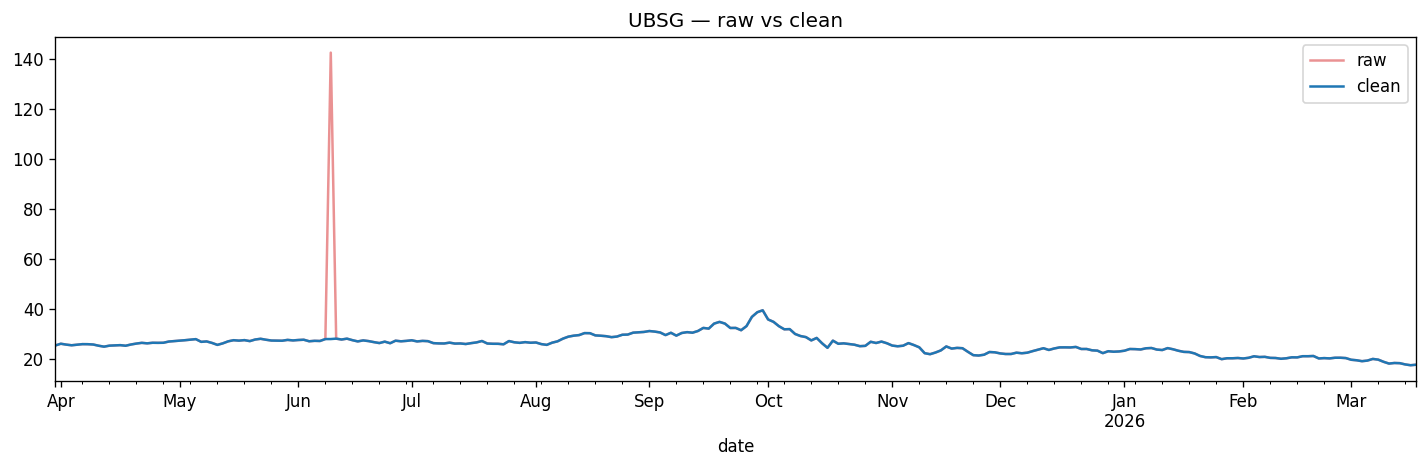

In [14]:
if len(outliers) > 0:
    outlier_ids = outliers["instrument_id"].unique()
    fig, axes = plt.subplots(len(outlier_ids), 1, figsize=(12, 4 * len(outlier_ids)), squeeze=False)
    for ax, iid in zip(axes[:, 0], outlier_ids, strict=True):
        raw_s   = raw[raw["instrument_id"] == iid].set_index("date")["price"]
        clean_s = clean[clean["instrument_id"] == iid].set_index("date")["price"]
        raw_s.plot(ax=ax, alpha=0.5, label="raw", color="tab:red")
        clean_s.plot(ax=ax, label="clean", color="tab:blue")
        ax.set_title(f"{iid} — raw vs clean")
        ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No outliers detected in raw prices.")

## 6. Returns

In [15]:
prices_wide = clean.pivot(index="date", columns="instrument_id", values="price").sort_index()
returns = prices_wide.pct_change().dropna(how="all")

print(f"Returns shape: {returns.shape}  ({returns.index.min()} → {returns.index.max()})")
returns.describe().T.sort_values("std", ascending=False).head(10)

Returns shape: (252, 18)  (2025-04-01 00:00:00 → 2026-03-18 00:00:00)


,count,mean,std,min,25%,50%,75%,max
instrument_id,,,,,,,,
ASML_NA,252.00,-0.00,0.03,-0.13,-0.02,-0.00,0.02,0.15
UBSG,252.00,-0.00,0.03,-0.09,-0.01,-0.00,0.01,0.12
SIE_GR,252.00,-0.00,0.02,-0.09,-0.01,-0.00,0.01,0.13
SREN,252.00,-0.00,0.02,-0.10,-0.01,-0.00,0.01,0.12
ALV_GR,252.00,-0.00,0.02,-0.09,-0.01,0.00,0.01,0.10
ABBN,252.00,-0.00,0.02,-0.12,-0.01,-0.00,0.01,0.10
SAN_FP,252.00,0.00,0.02,-0.09,-0.01,0.00,0.01,0.07
ROG,252.00,-0.00,0.02,-0.08,-0.01,-0.00,0.01,0.09
NOVN,252.00,-0.00,0.02,-0.08,-0.01,-0.00,0.01,0.10


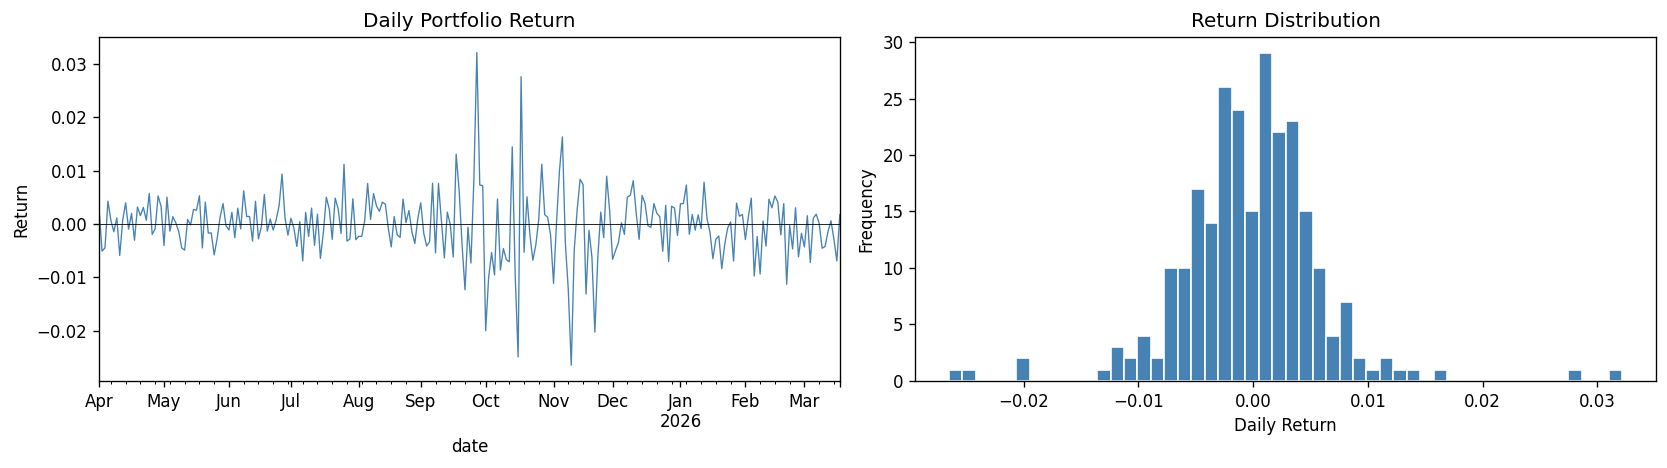

Annualised vol:  9.92%
Skewness:        0.185
Excess kurtosis: 5.936


In [16]:
weights = positions.set_index("instrument_id")["weight"]
common = returns.columns.intersection(weights.index)
port_returns = returns[common].dot(weights[common])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
port_returns.plot(ax=axes[0], title="Daily Portfolio Return", color="steelblue", linewidth=0.8)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_ylabel("Return")
port_returns.plot.hist(ax=axes[1], bins=50, title="Return Distribution", color="steelblue", edgecolor="white")
axes[1].set_xlabel("Daily Return")
plt.tight_layout()
plt.show()

print(f"Annualised vol:  {port_returns.std() * np.sqrt(252):.2%}")
print(f"Skewness:        {port_returns.skew():.3f}")
print(f"Excess kurtosis: {port_returns.kurt():.3f}")

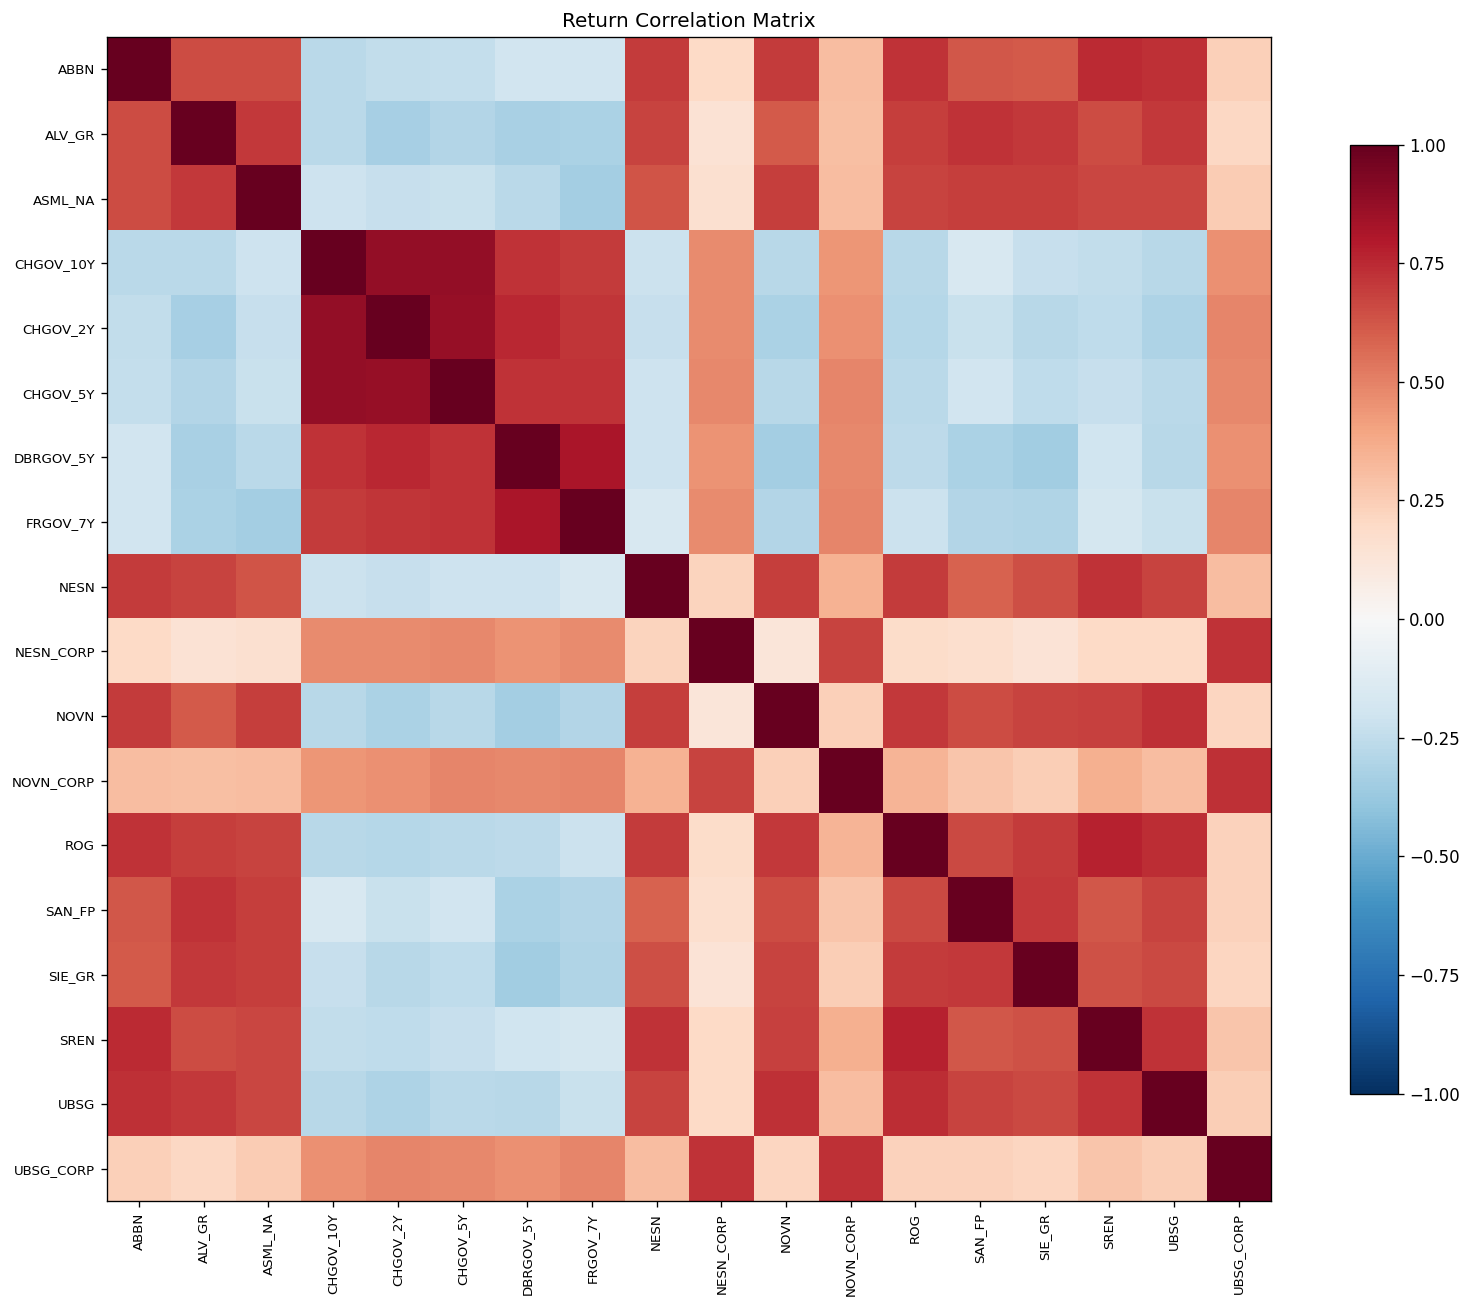

In [17]:
corr = returns[common].corr()

fig, ax = plt.subplots(figsize=(14, 11))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
plt.colorbar(im, ax=ax, fraction=0.03)
ticks = range(len(corr))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr.index, fontsize=8)
ax.set_title("Return Correlation Matrix")
plt.tight_layout()
plt.show()

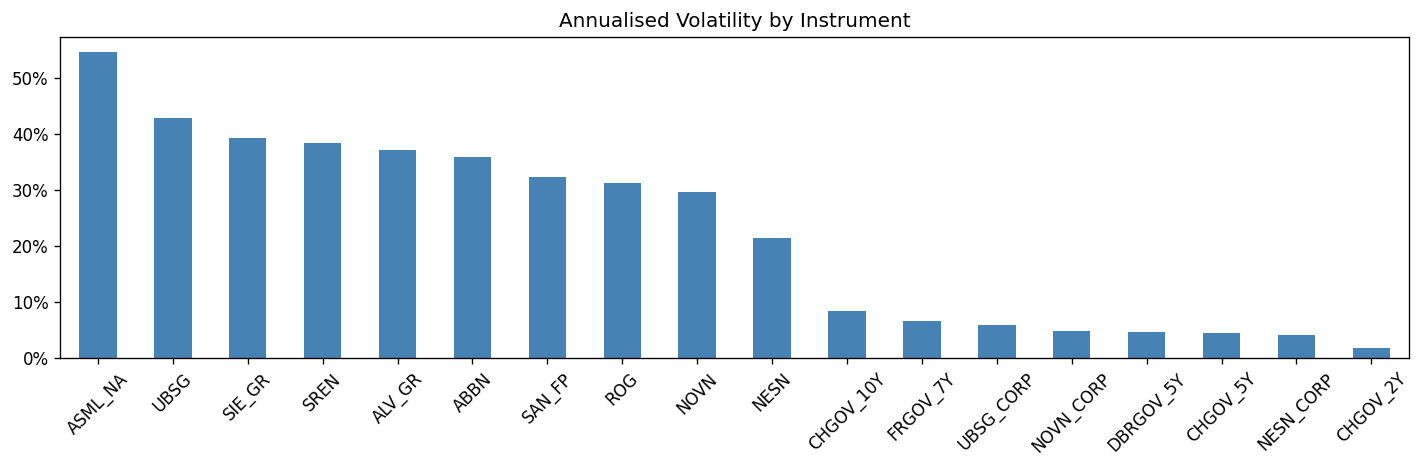

In [18]:
ann_vol = returns[common].std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(12, 4))
ann_vol.sort_values(ascending=False).plot.bar(
    ax=ax, color="steelblue", title="Annualised Volatility by Instrument"
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 7. Stress Scenarios

Shape: (54, 5)  |  Distinct scenarios: 3


,,instruments_shocked
scenario_id,scenario_name,
EQUITY_CRASH,Global Equity Market Crash,18
EU_SOVEREIGN_SPREAD,European Sovereign Debt Stress,18
SNB_RATE_SHOCK,SNB Emergency Rate Hike (+100bp),18


,scenario_id,scenario_name,instrument_id,shock_return,description
0,SNB_RATE_SHOCK,SNB Emergency Rate Hike (+100bp),NESN,-0.05,The SNB raises rates by 100bp unexpectedly to ...
1,SNB_RATE_SHOCK,SNB Emergency Rate Hike (+100bp),NOVN,-0.05,The SNB raises rates by 100bp unexpectedly to ...
2,SNB_RATE_SHOCK,SNB Emergency Rate Hike (+100bp),ROG,-0.05,The SNB raises rates by 100bp unexpectedly to ...
3,SNB_RATE_SHOCK,SNB Emergency Rate Hike (+100bp),UBSG,-0.10,The SNB raises rates by 100bp unexpectedly to ...
4,SNB_RATE_SHOCK,SNB Emergency Rate Hike (+100bp),ABBN,-0.06,The SNB raises rates by 100bp unexpectedly to ...
5,SNB_RATE_SHOCK,SNB Emergency Rate Hike (+100bp),SREN,-0.09,The SNB raises rates by 100bp unexpectedly to ...
6,SNB_RATE_SHOCK,SNB Emergency Rate Hike (+100bp),SAN_FP,-0.03,The SNB raises rates by 100bp unexpectedly to ...
7,SNB_RATE_SHOCK,SNB Emergency Rate Hike (+100bp),SIE_GR,-0.04,The SNB raises rates by 100bp unexpectedly to ...
8,SNB_RATE_SHOCK,SNB Emergency Rate Hike (+100bp),ASML_NA,-0.07,The SNB raises rates by 100bp unexpectedly to ...
9,SNB_RATE_SHOCK,SNB Emergency Rate Hike (+100bp),ALV_GR,-0.08,The SNB raises rates by 100bp unexpectedly to ...


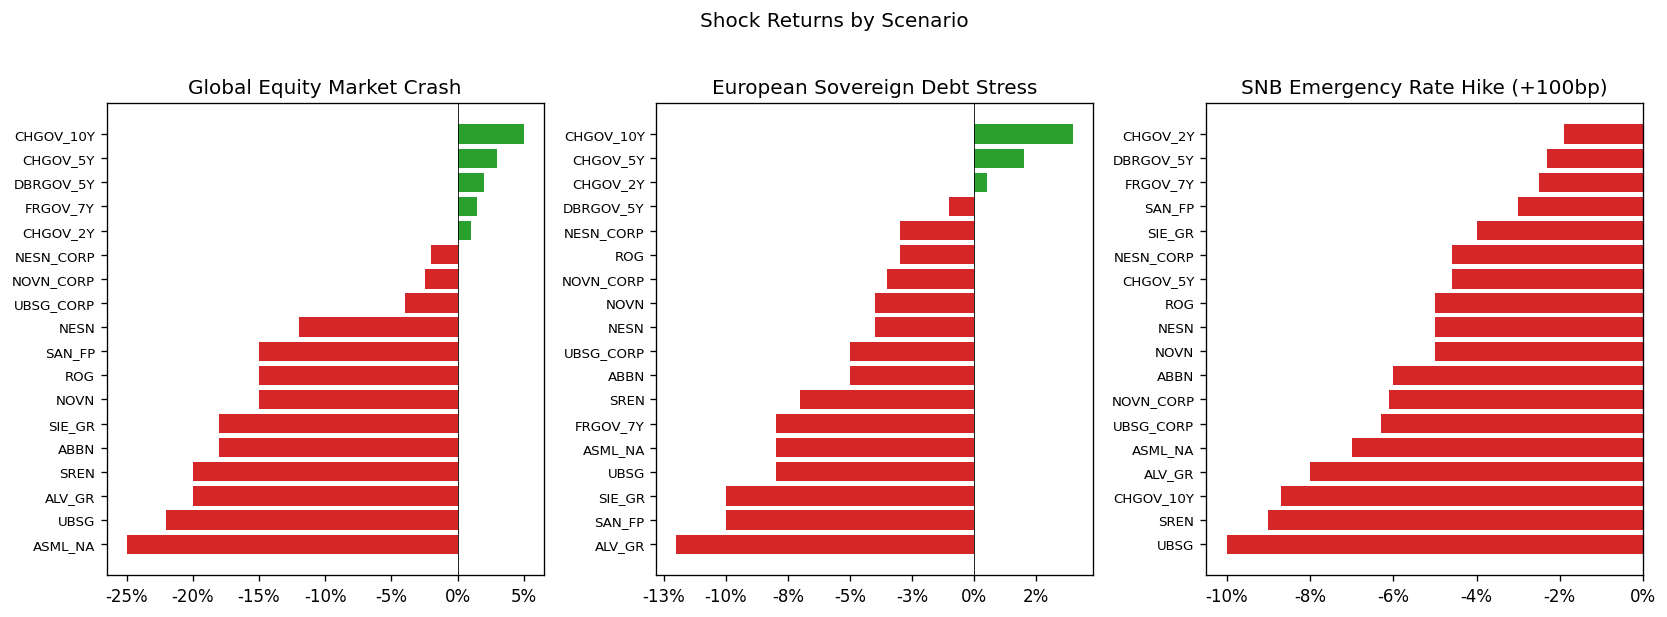

In [19]:
scenarios = load_scenarios()
print(f"Shape: {scenarios.shape}  |  Distinct scenarios: {scenarios['scenario_id'].nunique()}")
display(scenarios.groupby(["scenario_id", "scenario_name"]).size().rename("instruments_shocked").to_frame())
display(scenarios.head(15))

n_scenarios = scenarios["scenario_id"].nunique()
fig, axes = plt.subplots(1, n_scenarios, figsize=(14, 5), squeeze=False)

for ax, (_, grp) in zip(axes[0], scenarios.groupby("scenario_id"), strict=True):
    name = grp["scenario_name"].iloc[0]
    grp_sorted = grp.sort_values("shock_return")
    colors = ["tab:red" if x < 0 else "tab:green" for x in grp_sorted["shock_return"]]
    ax.barh(range(len(grp_sorted)), grp_sorted["shock_return"].values, color=colors)
    ax.set_yticks(range(len(grp_sorted)))
    ax.set_yticklabels(grp_sorted["instrument_id"].values, fontsize=8)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.set_title(name)

plt.suptitle("Shock Returns by Scenario", y=1.02)
plt.tight_layout()
plt.show()